# MNIST Full Dataset Exploration

## Objective
This notebook gives a complete inspection of the MNIST dataset used in this project:
- what arrays exist in the `.npz` file
- how many samples and what shapes/dtypes they have
- how labels are distributed
- how samples look as images
- pixel-intensity behavior
- how data is split into train/validation/test for binary experiments

In [ ]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features.mnist_features import (
    load_mnist,
    select_binary_classes,
    split_data,
    normalize_data,
    build_features,
)

## 1) Inspect Raw `.npz` Contents

In [ ]:
data_path = "../../data/mnist.npz"
raw = np.load(data_path)
print("Keys inside mnist.npz:", raw.files)

for key in raw.files:
    arr = raw[key]
    print(f"{key:>8} -> shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")

Data path: C:\Users\Ahmed Fahmy\Downloads\Projects\ML\Mnist-Classification\data\mnist.npz
Keys inside mnist.npz: ['x_test', 'x_train', 'y_train', 'y_test']
  x_test -> shape=(10000, 28, 28), dtype=uint8, min=0, max=255
 x_train -> shape=(60000, 28, 28), dtype=uint8, min=0, max=255
 y_train -> shape=(60000,), dtype=uint8, min=0, max=9
  y_test -> shape=(10000,), dtype=uint8, min=0, max=9


In [5]:
x_train_raw = raw["x_train"]
y_train_raw = raw["y_train"]
x_test_raw = raw["x_test"]
y_test_raw = raw["y_test"]

raw_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "images": x_train_raw.shape[0],
            "image_shape": x_train_raw.shape[1:],
            "labels": y_train_raw.shape[0],
        },
        {
            "split": "test",
            "images": x_test_raw.shape[0],
            "image_shape": x_test_raw.shape[1:],
            "labels": y_test_raw.shape[0],
        },
    ]
)
raw_summary

#x_train_raw[0][12]

,split,images,image_shape,labels
0,train,60000,"(28, 28)",60000
1,test,10000,"(28, 28)",10000


## 2) Label Distribution in Original Train/Test Splits

In [6]:
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts = pd.Series(y_test_raw).value_counts().sort_index()

label_df = pd.DataFrame({"train_count": train_counts, "test_count": test_counts})
label_df["train_pct"] = 100 * label_df["train_count"] / label_df["train_count"].sum()
label_df["test_pct"] = 100 * label_df["test_count"] / label_df["test_count"].sum()
label_df

,train_count,test_count,train_pct,test_pct
0,5923,980,9.871667,9.80
1,6742,1135,11.236667,11.35
2,5958,1032,9.930000,10.32
3,6131,1010,10.218333,10.10
4,5842,982,9.736667,9.82
5,5421,892,9.035000,8.92
6,5918,958,9.863333,9.58
7,6265,1028,10.441667,10.28
8,5851,974,9.751667,9.74
9,5949,1009,9.915000,10.09


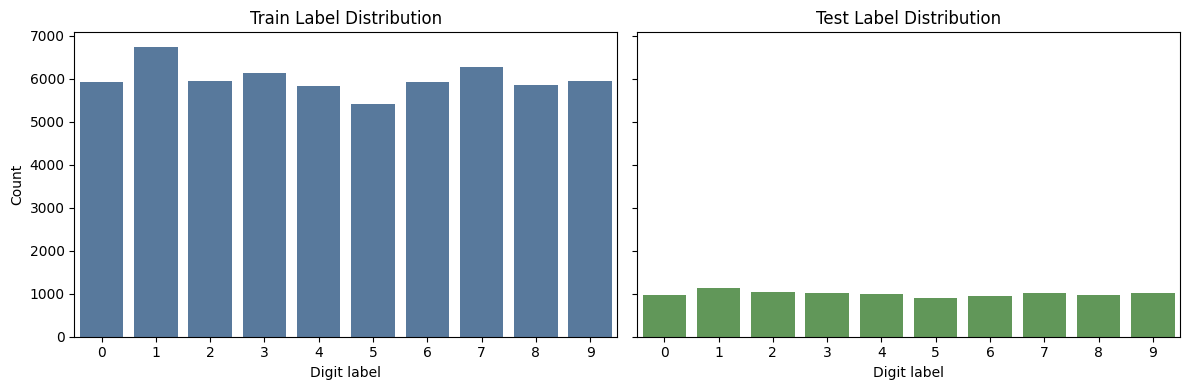

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color="#4C78A8")
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Digit label")
axes[0].set_ylabel("Count")

sns.barplot(x=test_counts.index, y=test_counts.values, ax=axes[1], color="#59A14F")
axes[1].set_title("Test Label Distribution")
axes[1].set_xlabel("Digit label")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 3) Merge Full Dataset and Check Overall Statistics

In [8]:
x_all, y_all = load_mnist(data_path)

print("Merged image array shape:", x_all.shape)
print("Merged label array shape:", y_all.shape)
print("Image dtype:", x_all.dtype)
print("Pixel range:", int(x_all.min()), "to", int(x_all.max()))
print("Number of unique labels:", np.unique(y_all).size)
print("Unique labels:", np.unique(y_all))

Merged image array shape: (70000, 28, 28)
Merged label array shape: (70000,)
Image dtype: uint8
Pixel range: 0 to 255
Number of unique labels: 10
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [9]:
overall_counts = pd.Series(y_all).value_counts().sort_index()
overall_df = pd.DataFrame({"count": overall_counts})
overall_df["percent"] = 100 * overall_df["count"] / overall_df["count"].sum()
overall_df

,count,percent
0,6903,9.861429
1,7877,11.252857
2,6990,9.985714
3,7141,10.201429
4,6824,9.748571
5,6313,9.018571
6,6876,9.822857
7,7293,10.418571
8,6825,9.750000
9,6958,9.940000


## 4) Visualize Samples as Images

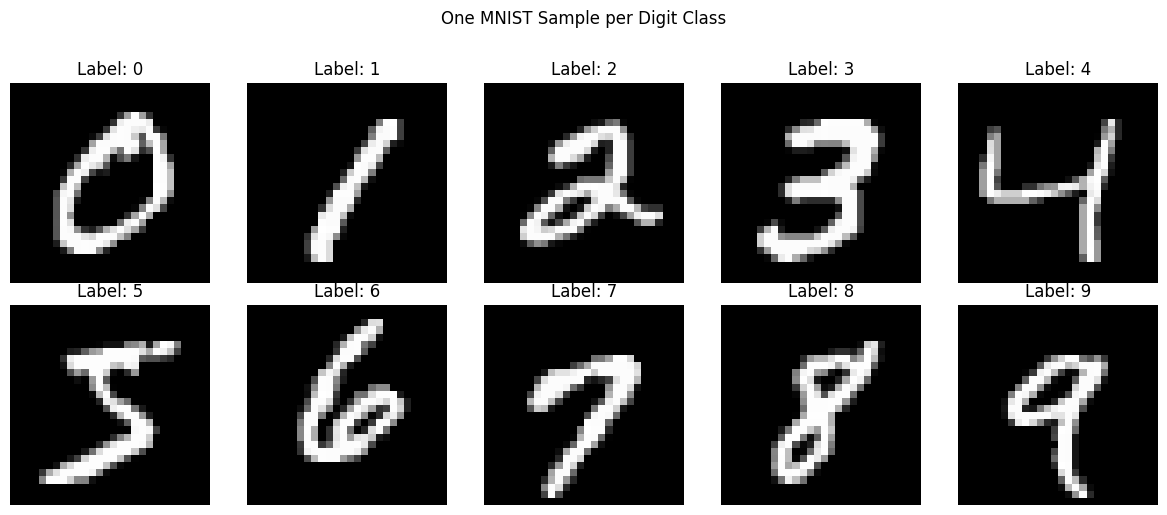

In [10]:
# One sample per digit label
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    idx = np.where(y_all == digit)[0][0]
    axes[digit].imshow(x_all[idx], cmap="gray")
    axes[digit].set_title(f"Label: {digit}")
    axes[digit].axis("off")

plt.suptitle("One MNIST Sample per Digit Class", y=1.02)
plt.tight_layout()
plt.show()

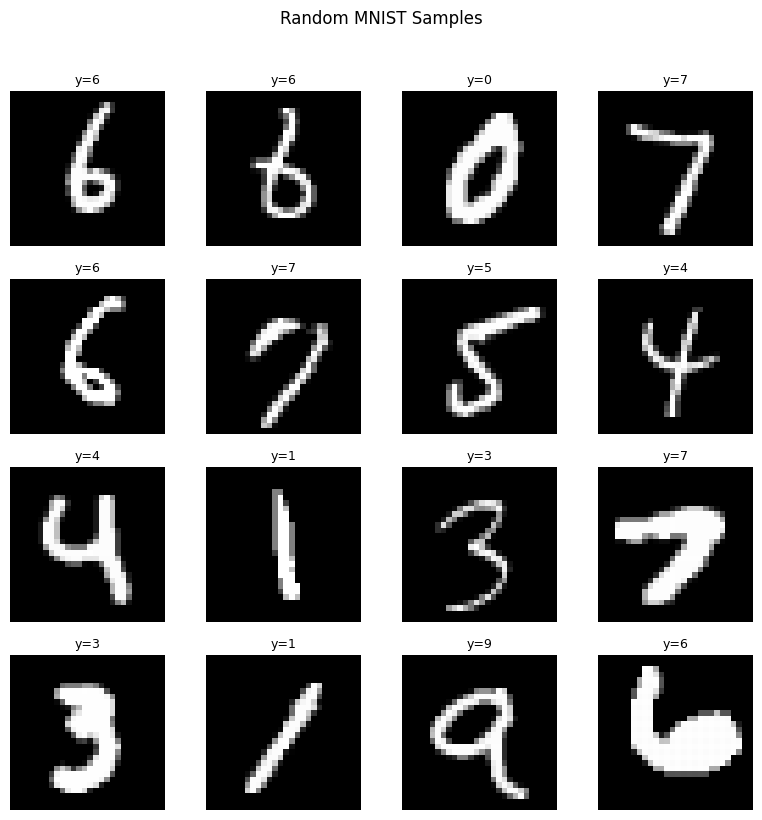

In [11]:
# Random samples from full dataset
rng = np.random.default_rng(42)
sample_ids = rng.choice(x_all.shape[0], size=16, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, idx in zip(axes.ravel(), sample_ids):
    ax.imshow(x_all[idx], cmap="gray")
    ax.set_title(f"y={int(y_all[idx])}", fontsize=9)
    ax.axis("off")

plt.suptitle("Random MNIST Samples", y=1.02)
plt.tight_layout()
plt.show()

## 5) Pixel-Level Inspection

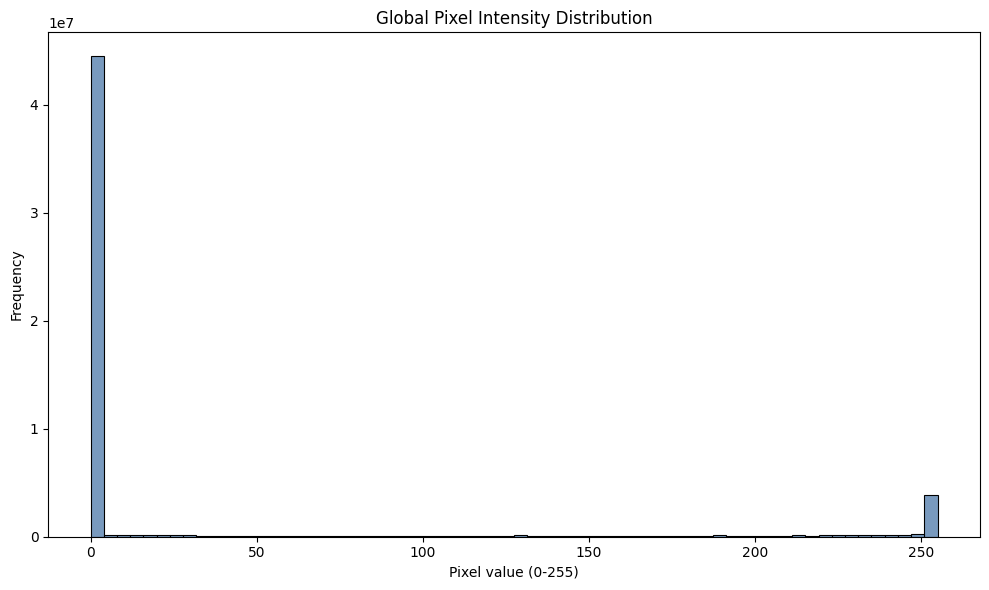

Pixel mean: 33.385964741253645
Pixel std: 78.6543736268941
Unique count: 256
First 20: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
Last 20: [236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253
 254 255]


In [12]:
# Distribution of pixel intensities over all images
pixel_values = x_all.reshape(-1)

plt.figure(figsize=(10, 6))
sns.histplot(pixel_values, bins=64, color="#4C78A8")
plt.title("Global Pixel Intensity Distribution")
plt.xlabel("Pixel value (0-255)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Pixel mean:", float(pixel_values.mean()))
print("Pixel std:", float(pixel_values.std()))

unique_vals = np.unique(pixel_values)
print("Unique count:", unique_vals.size)
print("First 20:", unique_vals[:20])
print("Last 20:", unique_vals[-20:])

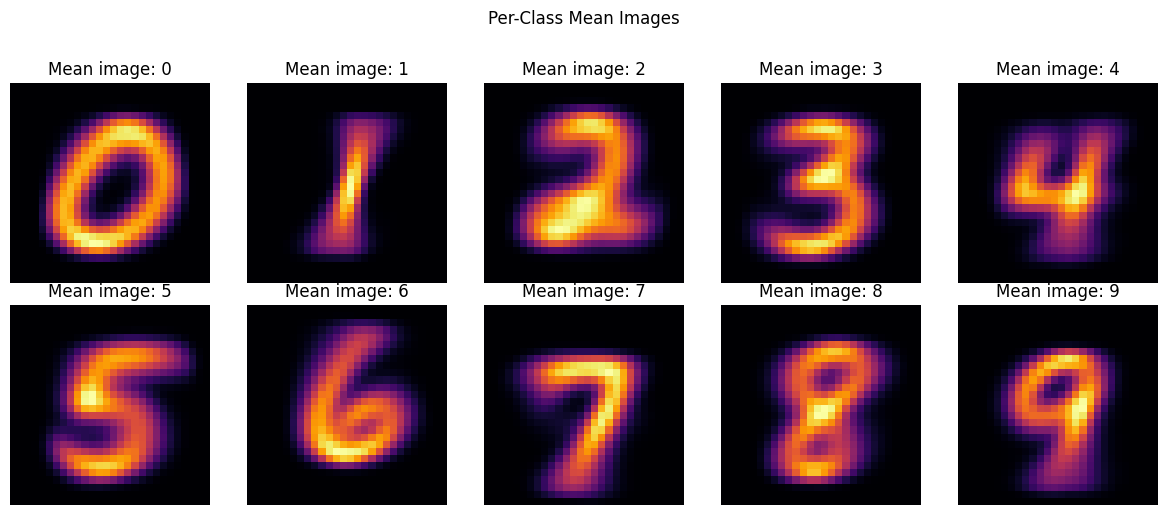

In [13]:
# Average image for each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()

for digit in range(10):
    mean_img = x_all[y_all == digit].mean(axis=0)
    axes[digit].imshow(mean_img, cmap="inferno")
    axes[digit].set_title(f"Mean image: {digit}")
    axes[digit].axis("off")

plt.suptitle("Per-Class Mean Images", y=1.02)
plt.tight_layout()
plt.show()

In [14]:
class_a, class_b = 0, 1
x_binary, y_binary = select_binary_classes(x_all, y_all, class_a, class_b)

print(f"Binary classes: {class_a} vs {class_b}")
print("Binary image shape:", x_binary.shape)
print("Binary label shape:", y_binary.shape)
print("Counts:", pd.Series(y_binary).value_counts().sort_index().to_dict())

Binary classes: 0 vs 1
Binary image shape: (14780, 28, 28)
Binary label shape: (14780,)
Counts: {0: 6903, 1: 7877}


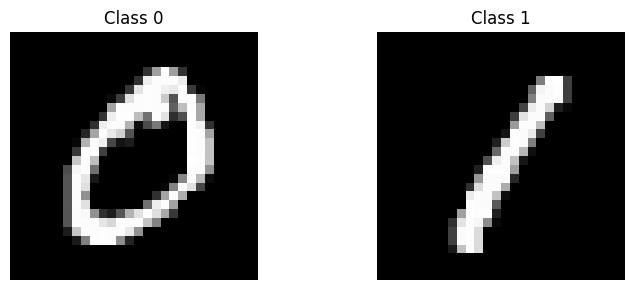

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, cls in enumerate([class_a, class_b]):
    idx = np.where(y_binary == cls)[0][0]
    axes[i].imshow(x_binary[idx], cmap="gray")
    axes[i].set_title(f"Class {cls}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 7) How Data Is Divided (Train/Validation/Test)

In [16]:
test_size = 0.2
val_size = 0.2
random_state = 42

x_train, y_train, x_val, y_val, x_test, y_test = split_data(
    x_binary,
    y_binary,
    test_size=test_size,
    val_size=val_size,
    random_state=random_state,
)

split_stats = pd.DataFrame(
    [
        {
            "split": "train",
            "samples": x_train.shape[0],
            "class_0": int((y_train == class_a).sum()),
            "class_1": int((y_train == class_b).sum()),
        },
        {
            "split": "validation",
            "samples": x_val.shape[0],
            "class_0": int((y_val == class_a).sum()),
            "class_1": int((y_val == class_b).sum()),
        },
        {
            "split": "test",
            "samples": x_test.shape[0],
            "class_0": int((y_test == class_a).sum()),
            "class_1": int((y_test == class_b).sum()),
        },
    ]
)
split_stats["class_0_pct"] = 100 * split_stats["class_0"] / split_stats["samples"]
split_stats["class_1_pct"] = 100 * split_stats["class_1"] / split_stats["samples"]
split_stats

,split,samples,class_0,class_1,class_0_pct,class_1_pct
0,train,8868,4105,4763,46.290032,53.709968
1,validation,2956,1396,1560,47.225981,52.774019
2,test,2956,1402,1554,47.428958,52.571042


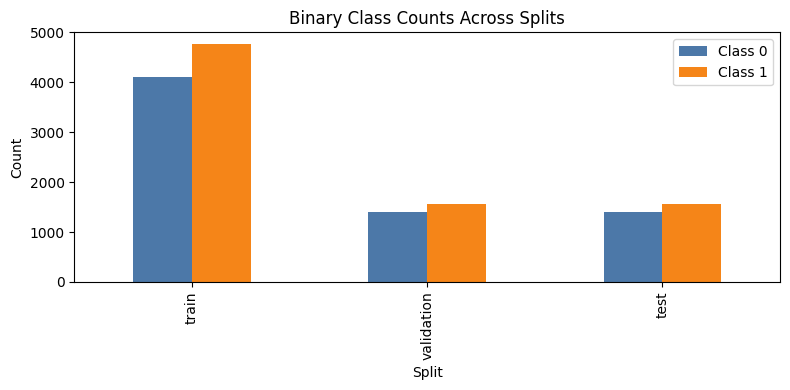

In [17]:
split_plot_df = split_stats.set_index("split")[["class_0", "class_1"]]
ax = split_plot_df.plot(kind="bar", figsize=(8, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Binary Class Counts Across Splits")
ax.set_xlabel("Split")
ax.set_ylabel("Count")
ax.legend([f"Class {class_a}", f"Class {class_b}"])
plt.tight_layout()
plt.show()

## 8) Feature Preparation Extras

These examples summarize the data-prep steps used in the project helpers:
- normalize pixel values to `[0, 1]`
- flatten images for classical models
- create PCA feature sets for dimensionality reduction
- create HOG feature sets for experimentation
- show the same data can also be reused for multiclass work

In [18]:
# Normalize and prepare standardized flatten features via project helpers
x_train_norm = normalize_data(x_train)
x_val_norm = normalize_data(x_val)
x_test_norm = normalize_data(x_test)

x_train_flat, x_val_flat, x_test_flat = build_features(
    mode="flatten",
    x_train=x_train_norm,
    x_val=x_val_norm,
    x_test=x_test_norm,
)

print("Normalized train range:", float(x_train_norm.min()), "to", float(x_train_norm.max()))
print("Flattened train shape:", x_train_flat.shape)
print("Flattened validation shape:", x_val_flat.shape)
print("Flattened test shape:", x_test_flat.shape)

Normalized train range: 0.0 to 1.0
Flattened train shape: (8868, 784)
Flattened validation shape: (2956, 784)
Flattened test shape: (2956, 784)


In [19]:
# Prepare standardized HOG features via project helpers
x_train_hog, x_val_hog, x_test_hog = build_features(
    mode="hog",
    x_train=x_train_norm,
    x_val=x_val_norm,
    x_test=x_test_norm,
)

print("HOG train shape:", x_train_hog.shape)
print("HOG validation shape:", x_val_hog.shape)
print("HOG test shape:", x_test_hog.shape)

HOG train shape: (8868, 1296)
HOG validation shape: (2956, 1296)
HOG test shape: (2956, 1296)


In [21]:
# Prepare PCA features via project helpers (single train-fitted transform)
x_train_pca, x_val_pca, x_test_pca = build_features(
    mode="pca",
    x_train=x_train_norm,
    x_val=x_val_norm,
    x_test=x_test_norm,
    pca_components=0.95,
    random_state=42,
)

print("PCA train shape:", x_train_pca.shape)
print("PCA validation shape:", x_val_pca.shape)
print("PCA test shape:", x_test_pca.shape)

PCA train shape: (8868, 96)
PCA validation shape: (2956, 96)
PCA test shape: (2956, 96)


## 8.1) PCA and HOG Visualizations

These plots make the feature transforms easier to inspect:
- PCA: a 2D scatter of the first two principal components
- HOG: the original image next to its HOG descriptor visualization

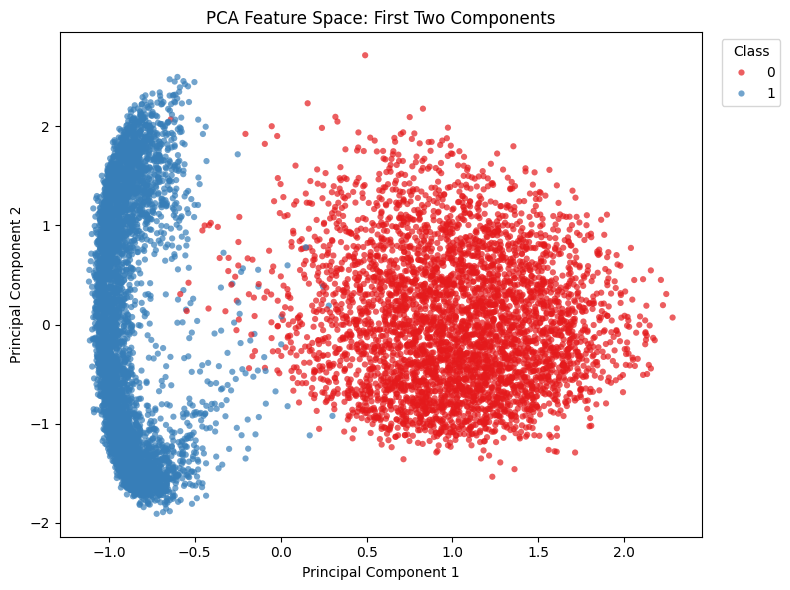

In [24]:
# PCA visualization: first two components from the train split
if x_train_pca.shape[1] < 2:
    print("PCA visualization needs at least 2 components, but only one component is available.")
else:
    pca_plot_df = pd.DataFrame(
        {
            "pc1": x_train_pca[:, 0],
            "pc2": x_train_pca[:, 1],
            "label": y_train,
        }
    )

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=pca_plot_df,
        x="pc1",
        y="pc2",
        hue="label",
        palette="Set1",
        s=20,
        alpha=0.7,
        linewidth=0,
    )
    plt.title("PCA Feature Space: First Two Components")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

First 5 samples, first 10 PCA component values:


,pc_1,pc_2,pc_3,pc_4,pc_5,pc_6,pc_7,pc_8,pc_9,pc_10
0,-2.456108,-3.147213,-0.699346,0.402482,-1.844656,2.077648,0.491049,-0.563103,-0.409713,0.957882
1,3.401352,-0.277278,1.512214,-2.476394,1.090275,3.181082,-3.286546,-1.309781,-1.804854,-0.228931
2,-3.374960,-3.467638,-1.364178,-0.094417,-0.878814,1.510173,1.081848,-0.662291,0.126820,-0.229154
3,-3.635564,1.473114,1.420838,0.122557,-1.053247,-0.618537,-0.886979,-0.050343,-0.557412,0.785401
4,-4.008585,-1.653135,-0.400758,-0.675438,0.305395,-1.009895,-0.860315,0.788950,-0.279890,-0.768862


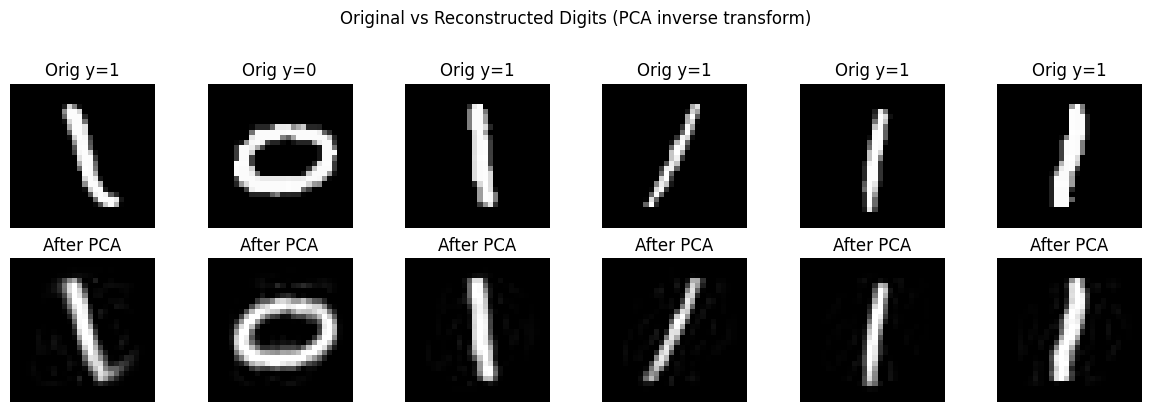

PCA components kept: 96
Explained variance ratio sum: 0.9501485228538513


In [27]:
from sklearn.decomposition import PCA

# Show PCA numeric values and reconstructed digits
x_train_flat_unstd = x_train_norm.reshape(x_train_norm.shape[0], -1)
pca_vis = PCA(n_components=0.95, random_state=42)
x_train_pca_unstd = pca_vis.fit_transform(x_train_flat_unstd)

pca_numbers_df = pd.DataFrame(x_train_pca_unstd[:5, :10], columns=[f"pc_{i+1}" for i in range(10)])
print("First 5 samples, first 10 PCA component values:")
display(pca_numbers_df)

reconstructed_flat = pca_vis.inverse_transform(x_train_pca_unstd)
reconstructed_imgs = reconstructed_flat.reshape(-1, 28, 28)

show_n = 6
fig, axes = plt.subplots(2, show_n, figsize=(2 * show_n, 4))
for i in range(show_n):
    axes[0, i].imshow(x_train_norm[i], cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"Orig y={int(y_train[i])}")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructed_imgs[i], cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("After PCA")
    axes[1, i].axis("off")

fig.suptitle("Original vs Reconstructed Digits (PCA inverse transform)", y=1.02)
plt.tight_layout()
plt.show()

print("PCA components kept:", pca_vis.n_components_)
print("Explained variance ratio sum:", float(pca_vis.explained_variance_ratio_.sum()))

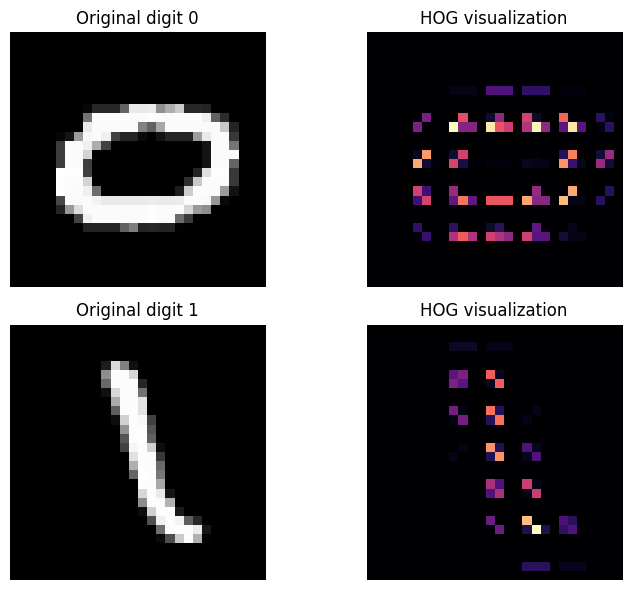

In [25]:
from skimage.feature import hog

# HOG visualization: original image next to its descriptor visualization
sample_indices = [
    np.where(y_train == class_a)[0][0],
    np.where(y_train == class_b)[0][0],
]

fig, axes = plt.subplots(len(sample_indices), 2, figsize=(8, 6))
if len(sample_indices) == 1:
    axes = np.array([axes])

for row, idx in enumerate(sample_indices):
    image = x_train[idx]
    _, hog_image = hog(
        image,
        pixels_per_cell=(4, 4),
        cells_per_block=(2, 2),
        orientations=9,
        visualize=True,
        feature_vector=True,
    )

    axes[row, 0].imshow(image, cmap="gray")
    axes[row, 0].set_title(f"Original digit {int(y_train[idx])}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(hog_image, cmap="magma")
    axes[row, 1].set_title("HOG visualization")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 9) Final Notes

This notebook shows:
- raw file structure and all arrays
- label distributions in train/test and merged data
- sample images and per-class mean images
- pixel intensity statistics
- binary subset extraction
- exact train/validation/test split composition
- normalization, flattening, PCA, and HOG feature prep examples